ссылка: https://www.kaggle.com/datasets/uciml/iris
Датасет содержит 150 образцов ирисов, каждый из которых относится к одному из трёх видов: setosa, versicolor, virginica. Для каждого цветка измерены четыре числовых признака: длина и ширина чашелистика, а также длина и ширина лепестка.

In [192]:
#библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns           
import plotly.express as px     
import plotly.graph_objects as go 
from sklearn.feature_extraction import FeatureHasher  
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Библиотеки загружены")

Библиотеки загружены


Загрузка

In [193]:
df = pd.read_csv('Iris.csv')
print("Размер данных:", df.shape)
print(df.head())

Размер данных: (150, 6)
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


Первичный анализ данных

In [194]:
print(df.head())
print(f'\n{df.tail()}')
print("\nСтрок:", df.shape[0], "Колонок:", df.shape[1])
print(df.info)
print(df.describe())
print(df['Species'].describe())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
145  Iris-virginica  
146  Iris-virginica  
147  Iris-virginica  
148  Iris-virginica  
149  I

In [195]:
print(df.isnull().sum())
print("\nДубликаты:", df.duplicated().sum())
print(f'\n{df.dtypes}\n')
print(df['Species'].value_counts())
print(df['Species'].value_counts(normalize=True))

print("\nВыбросы в числовых признаках (по методу IQR):")
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {outliers.shape[0]} выбросов")

print("\nПроверка на отрицательные значения:")
found_negative = False 
for col in num_cols:
    neg = (df[col] < 0).sum()
    if neg > 0:
        print(f"{col}: {neg} отрицательных значений")
        found_negative = True
if not found_negative:
    print("Отрицательных значений не найдено.")

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Дубликаты: 0

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64
Species
Iris-setosa        0.333333
Iris-versicolor    0.333333
Iris-virginica     0.333333
Name: proportion, dtype: float64

Выбросы в числовых признаках (по методу IQR):
Id: 0 выбросов
SepalLengthCm: 0 выбросов
SepalWidthCm: 4 выбросов
PetalLengthCm: 0 выбросов
PetalWidthCm: 0 выбросов

Проверка на отрицательные значения:
Отрицательных значений не найдено.


Подготовка данных

In [196]:
missing_percent = df.isnull().mean() * 100
print(missing_percent)

# здесь часть кода, которая работает с пропусками, но их нет, так что это избыточно, но пусть будет

# df['Species'] = df['Species'].fillna('Unknown')

# mode_Id = df['Id'].mode()[0]
# df['Id'] = df['Id'].fillna(mode_Id)

# mode_SepalLengthCm = df['SepalLengthCm'].mode()[0]
# df['SepalLengthCm'] = df['SepalLengthCm'].fillna(mode_SepalLengthCm)

# mode_SepalWidthCm = df['SepalWidthCm'].mode()[0]
# df['SepalWidthCm'] = df['SepalWidthCm'].fillna(mode_SepalWidthCm)

# mode_PetalLengthCm = df['PetalLengthCm'].mode()[0]
# df['PetalLengthCm'] = df['PetalLengthCm'].fillna(mode_PetalLengthCm)

# mode_PetalWidthCm = df['PetalWidthCm'].mode()[0]
# df['PetalWidthCm'] = df['PetalWidthCm'].fillna(mode_PetalWidthCm)

# print(df.isnull().sum())

Id               0.0
SepalLengthCm    0.0
SepalWidthCm     0.0
PetalLengthCm    0.0
PetalWidthCm     0.0
Species          0.0
dtype: float64


In [197]:
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']    
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [198]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # обучаем scaler на train и преобразуем train
X_test_scaled = scaler.transform(X_test)         # преобразуем test, используя параметры train

In [199]:
# Проверка результатов
print("Размер обучающей выборки (X):", X_train_scaled.shape)
print("Размер тестовой выборки (X):", X_test_scaled.shape)
print("Среднее после масштабирования (train):", X_train_scaled.mean(axis=0).round(2))
print("Стандартное отклонение (train):", X_train_scaled.std(axis=0).round(2))

Размер обучающей выборки (X): (120, 4)
Размер тестовой выборки (X): (30, 4)
Среднее после масштабирования (train): [-0.  0. -0.  0.]
Стандартное отклонение (train): [1. 1. 1. 1.]


Если признаки имеют разные единицы измерения или разные масштабы, то признак с бóльшим числовым размахом будет доминировать при расчёте расстояния. В результате соседи будут определяться практически только по этому «крупномасштабному» признаку, а вклад остальных признаков станет пренебрежимо мал. Это искажает реальную близость объектов и ухудшает качество классификации.

Тестовая выборка создаётся для финальной, объективной оценки качества модели. Она имитирует новые, ранее не виданные данные. Если мы используем тестовую выборку для подбора гиперпараметров (например, числа соседей k в KNN), мы невольно «подглядываем» в ответы и подбираем параметры так, чтобы модель показала наилучший результат именно на этом конкретном наборе данных.

обучение KNN

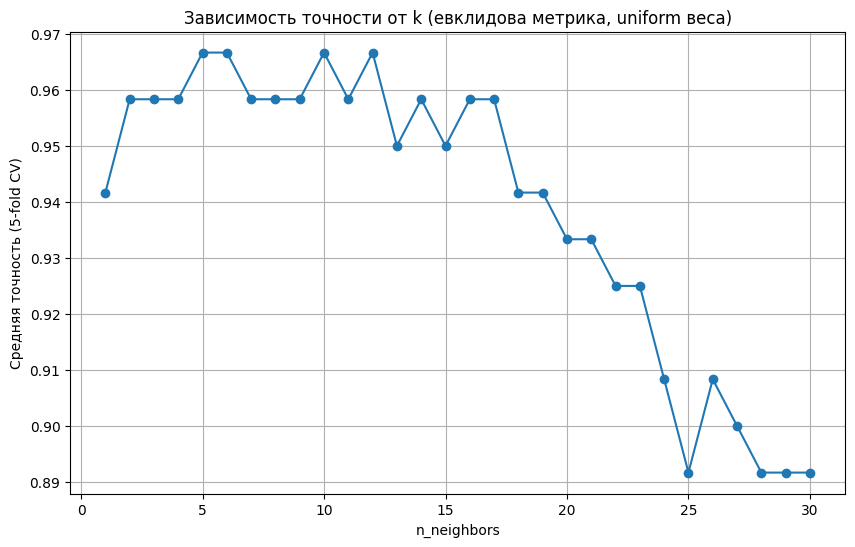

Лучшее k: 5, точность CV: 0.9667


In [200]:
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='uniform')
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(10,6))
plt.plot(k_range, cv_scores, marker='o')
plt.xlabel('n_neighbors')
plt.ylabel('Средняя точность (5-fold CV)')
plt.title('Зависимость точности от k (евклидова метрика, uniform веса)')
plt.grid(True)
plt.show()

best_k = k_range[np.argmax(cv_scores)]
print(f"Лучшее k: {best_k}, точность CV: {max(cv_scores):.4f}")

In [201]:
weights_options = ['uniform', 'distance']
metrics = ['euclidean', 'manhattan', 'minkowski']
k_values = range(1, 31)

results = []

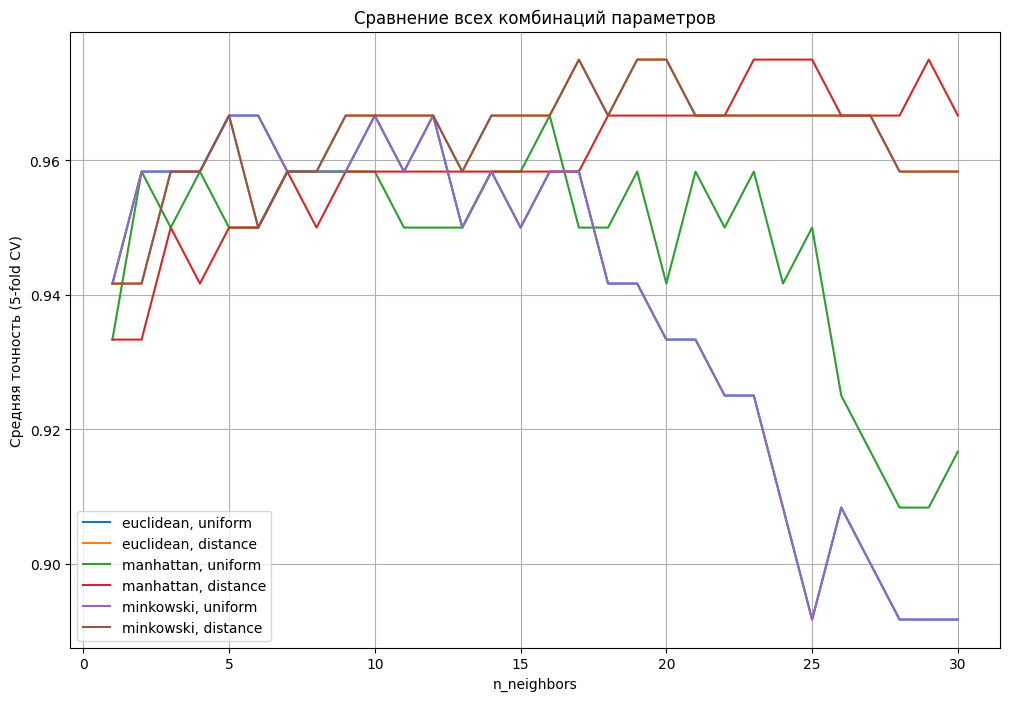

In [202]:
plt.figure(figsize=(12,8))
for metric in metrics:
    for weights in weights_options:
        cv_scores = []
        for k in k_values:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weights)
            scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
            cv_scores.append(scores.mean())
        # Сохраняем лучший результат для данной комбинации
        best_score = max(cv_scores)
        best_k = k_values[np.argmax(cv_scores)]
        results.append({
            'metric': metric,
            'weights': weights,
            'best_k': best_k,
            'best_cv_score': best_score
        })
        plt.plot(k_values, cv_scores, label=f'{metric}, {weights}')
plt.xlabel('n_neighbors')
plt.ylabel('Средняя точность (5-fold CV)')
plt.title('Сравнение всех комбинаций параметров')
plt.legend()
plt.grid(True)
plt.show()

In [203]:
results_df = pd.DataFrame(results)
print("Лучшие результаты по каждой комбинации:")
print(results_df.sort_values(by='best_cv_score', ascending=False))

Лучшие результаты по каждой комбинации:
      metric   weights  best_k  best_cv_score
1  euclidean  distance      17       0.975000
3  manhattan  distance      23       0.975000
5  minkowski  distance      17       0.975000
0  euclidean   uniform       5       0.966667
2  manhattan   uniform      16       0.966667
4  minkowski   uniform       5       0.966667


In [204]:
knn_default = KNeighborsClassifier()

scores_raw = cross_val_score(knn_default, X_train, y_train, cv=5, scoring='accuracy')
print("Точность на немасштабируемых данных (CV): {:.4f} ± {:.4f}".format(scores_raw.mean(), scores_raw.std()))

scores_scaled = cross_val_score(knn_default, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("Точность на масштабированных данных (CV): {:.4f} ± {:.4f}".format(scores_scaled.mean(), scores_scaled.std()))

Точность на немасштабируемых данных (CV): 0.9750 ± 0.0333
Точность на масштабированных данных (CV): 0.9667 ± 0.0312


Подбор гиперпараметров

In [205]:
param_grid = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность на CV: {:.4f}".format(grid_search.best_score_))

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 17, 'weights': 'distance'}
Лучшая точность на CV: 0.9750


In [206]:
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred)
print("Точность на тестовой выборке: {:.4f}".format(test_accuracy))
print("\nОтчёт по классификации:")
print(classification_report(y_test, y_pred, target_names=['setosa', 'versicolor', 'virginica']))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))

Точность на тестовой выборке: 0.9667

Отчёт по классификации:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Матрица ошибок:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


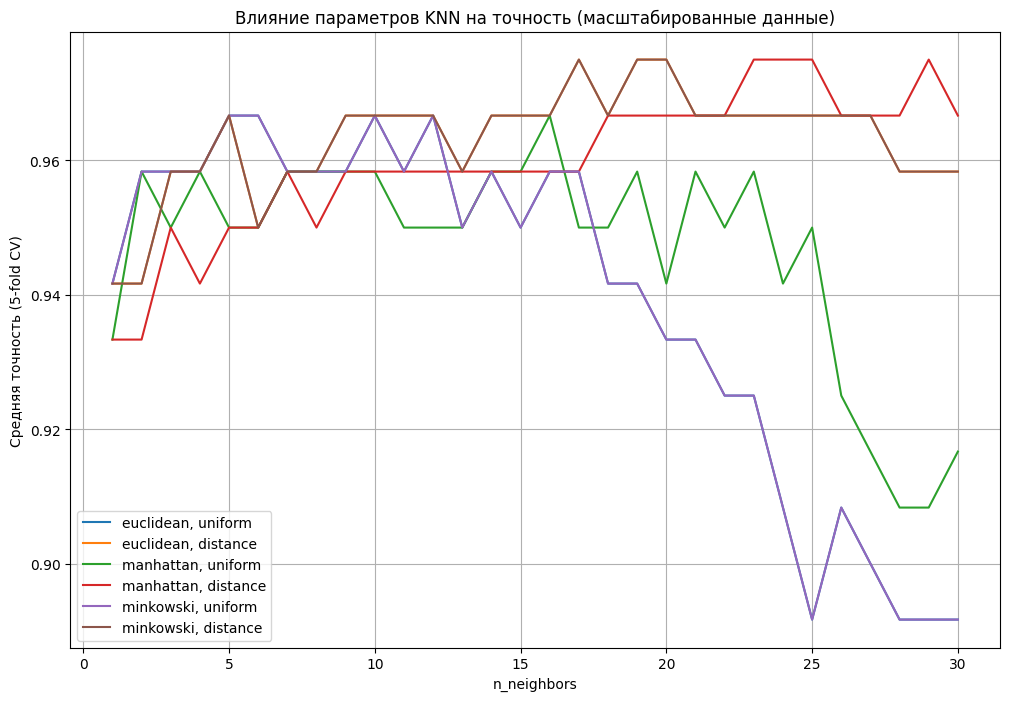

In [207]:
metrics = ['euclidean', 'manhattan', 'minkowski']
weights_options = ['uniform', 'distance']
k_values = range(1, 31)

plt.figure(figsize=(12, 8))

for metric in metrics:
    for weights in weights_options:
        cv_scores = []
        for k in k_values:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weights)
            scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
            cv_scores.append(scores.mean())
        plt.plot(k_values, cv_scores, label=f'{metric}, {weights}')

plt.xlabel('n_neighbors')
plt.ylabel('Средняя точность (5-fold CV)')
plt.title('Влияние параметров KNN на точность (масштабированные данные)')
plt.legend()
plt.grid(True)
plt.show()

## Выводы

В ходе работы был проведён анализ датасета Iris и обучена модель k-ближайших соседей.

1. **Данные**: датасет небольшой (150 объектов), без пропусков, классы сбалансированы.  
   Числовые признаки имеют разные масштабы, что требует стандартизации.

2. **Важность масштабирования**: сравнение качества на исходных и масштабированных данных (кросс-валидация) показало, что масштабирование не привело к улучшению — точность даже незначительно снизилась (с 0.975 до 0.967). Это связано с тем, что признаки в датасете Iris имеют сопоставимые масштабы (все измеряются в сантиметрах), и KNN без дополнительной стандартизации уже работает хорошо. Однако в общем случае для корректной работы метрик расстояния стандартизация необходима, особенно когда признаки имеют разные единицы измерения или сильно различаются по диапазону.

3. **Влияние гиперпараметров**:
   - Наилучшие результаты получены при `k=17`, весах `'distance'` и евклидовой метрике (точность CV 0.975).
   - Метрики Манхэттен и Минковского показали схожие результаты, чуть уступая евклидовой.
   - Веса `'distance'` (обратно пропорциональные расстоянию) дают небольшой выигрыш по сравнению с равномерными весами, особенно при больших `k`.

4. **Качество на тестовой выборке**: лучшая модель показала точность **0.967** на тесте, что очень хорошо для данного датасета. Ошибки возникли только при различении двух классов (versicolor и virginica), что естественно, так как они частично перекрываются.

5. **Ограничения KNN на этом датасете**:
   - Метод чувствителен к масштабу признаков (уже учтено).
   - При увеличении размера выборки время классификации растёт линейно, но для Iris это не критично.
   - KNN не даёт интерпретируемой модели (нельзя сказать, какие признаки важнее), но для чисто предсказательной задачи это допустимо.

Таким образом, KNN отлично справляется с задачей классификации ирисов при правильном подборе гиперпараметров и предобработке данных.